# Análise de Conteúdo com Discurso do Sujeito Coletivo (DSC) usando Python

> O método "Discurso do Sujeito Coletivo" (DSC) foi proposto por Fernando Lefèvre e Ana Maria Cavalcanti Lefèvre, professores da Faculdade de Saúde Pública da USP (Universidade de São Paulo), no campo da pesquisa qualitativa.

LEFEVRE F; LEFEVRE A.M.C. **O discurso do sujeito coletivo: um novo enfoque em pesquisaqualitativa (desdobramentos)**. Caxias do Sul: EDUCS, p. 256. 2003.

#### Setup de módulos

In [1]:
!pip install spacy
!pip install pandas
!pip install nltk
!pip install matplotlib
!pip install openai

#### Importando bibliotecas

In [2]:
import csv
import os
import spacy
import pandas as pd
from nltk import FreqDist
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import re
import openai
import textwrap
from IPython.display import HTML

#### Obtendo respostas das entrevistas

In [4]:
# Arquivo de entrada
arquivo_texto = 'respostas.txt'

# Arquivo da saída
arquivo_saida = 'respostas.csv'

# Obter arquivo entrada e ler conteúdo
with open(arquivo_texto, 'r', encoding='utf-8') as arquivo_entrada:
    linhas = arquivo_entrada.readlines()

# Removendo caracteres de nova
linhas = [linha.strip() for linha in linhas]

# Criar o CSV
with open(arquivo_saida, 'w', newline='', encoding='utf-8') as arquivo_saida:
    csv_writer = csv.writer(arquivo_saida, quoting=csv.QUOTE_ALL)
    csv_writer.writerow(["Respostas"])
    for linha in linhas:
        csv_writer.writerow([linha])

#### Definindo Expressões Chave e categorizando as Ideias Centrais

In [3]:
# Carregando modelo da língua portuguesa
nlp = spacy.load('pt_core_news_sm')

# Carregando respostas dos entrevistados
caminho_completo = os.path.join(os.getcwd(), 'respostas.csv')
ds_respostas = pd.read_csv(caminho_completo, header=0)

respostas = ds_respostas['Respostas'].tolist()

for resposta in respostas:
    print(resposta)

# Realizar análise para Ideia Central do Discurso do Sujeito Coletivo
def analise_sujeito_coletivo(respostas):
    sujeito_coletivo = []

    for resposta in respostas:
        doc = nlp(resposta)

        # Extrair entidades nomeadas
        entidades_nomeadas = [ent.text for ent in doc.ents]

        # Extrair palavras-chave (substantivos e adjetivos)
        palavras_chave = [token.text for token in doc if token.pos_ in ['NOUN', 'ADJ']]

        # Combinar entidades e palavras-chave para formar a Ideia Central
        discurso_sujeito_coletivo = entidades_nomeadas + palavras_chave

        sujeito_coletivo.append(" ".join(discurso_sujeito_coletivo))

    return sujeito_coletivo

# Realizar a análise
resultados_respostas = analise_sujeito_coletivo(respostas)

# Criando DataFrame
df = pd.DataFrame(resultados_respostas, columns=['Ideia Central'], index=['Ideia Central 1', 'Ideia Central 2', 'Ideia Central 3', 'Ideia Central 4'])

# Exibindo o texto completo
pd.set_option('display.max_colwidth', None)

# Visualizar o DataFrame
print(df)


Em nosso departamento, a colaboração entre equipes multifuncionais é uma vantagem competitiva ao adotar DevOps.
Em busca de eficiência na entrega de software, encontramos no DevOps um caminho viável para atingir nossos objetivos.
Os benefícios da eficiência operacional com DevOps são tangíveis em nossa empresa de médio porte.
Nosso objetivo era aprimorar a eficiência na entrega de software, e DevOps ofereceu um caminho sólido e eficaz para alcançar essa meta.
                                                                                Ideia Central
Ideia Central 1  DevOps departamento colaboração equipes multifuncionais vantagem competitiva
Ideia Central 2             DevOps busca eficiência entrega software caminho viável objetivos
Ideia Central 3        DevOps benefícios eficiência operacional tangíveis empresa médio porte
Ideia Central 4        DevOps objetivo eficiência entrega software caminho sólido eficaz meta


##### Gráfico de distribuição dos dados categóricos

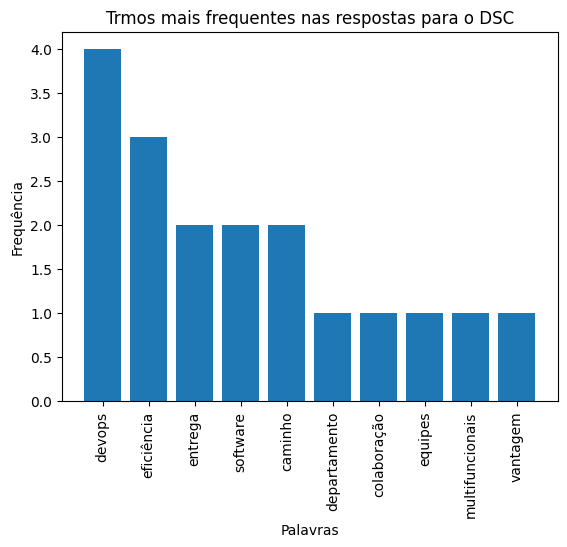

In [5]:
# Obtendo a coluna 'Respostas' contendo os dados do DSC
dsc_responses = ds_respostas['Respostas']

# Concatenando todas as respostas do DSC em uma única string
full_text = ' '.join(dsc_responses)

# Removendo pontuações e convertendo minúsculas
clean_text = re.sub(r'[^\w\s]', '', full_text.lower())

# Tokenizando o texto para dividir em palavras
words = clean_text.split()

# Removendo stopwords em português
stop_words = set(stopwords.words('portuguese'))
filtered_words = [word for word in words if word not in stop_words]

# Criando uma distribuição de frequência das palavras
freq_dist = FreqDist(filtered_words)

# Plotando as top 10 palavras mais frequentes
top_words = freq_dist.most_common(10)
labels, values = zip(*top_words)
plt.bar(labels, values)
plt.title('Trmos mais frequentes nas respostas para o DSC')
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.xticks(rotation='vertical')
plt.show()

#### Obtendo uma lista de modelos
Para gerar a chave API na conta da OpenAI basta:
1. Criar uma conta no site: https://platform.openai.com/signup
2. Clicar no ícone do OpenAI que fica no canto superior direito da tela, e depois clique na opção "API keys".
3. Clicar em "Create new secret key", depois copiar a chave gerada.

O resultado final do valor deve ser algo parecido com: "sk-js4rL9e3OBr6B67mx2YwT5BlbkFJ4otgcWD08MX0VLkRG9In"

In [6]:
# Chave da API OpenAI
openai.api_key = '<YOUR_API_KEY>'

# Obter a lista de modelos disponíveis
models_openai = openai.Engine.list()
models = [model for model in models_openai['data']]

for model in models:
    print(model['id'])

curie-search-query
babbage-search-query
dall-e-3
babbage-search-document
dall-e-2
gpt-3.5-turbo-0301
text-embedding-ada-002
davinci-search-query
tts-1-hd-1106
tts-1-hd
ada-search-document
ada-code-search-code
davinci-002
babbage-002
davinci-search-document
curie-search-document
whisper-1
ada-search-query
ada-code-search-text
gpt-3.5-turbo-16k-0613
gpt-3.5-turbo-16k
gpt-3.5-turbo
gpt-3.5-turbo-0613
gpt-3.5-turbo-1106
gpt-3.5-turbo-instruct
gpt-3.5-turbo-instruct-0914
tts-1-1106
tts-1


#### Realizando Análise do Discurso do Sujeito Coletivo
*As respostas são adicionadas como mensagens do usuário, criando assim um contexto para o modelo gerando um parágrafo continuado a partir dessas mensagens. O modelo utilizado deve ser capaz de lidar com sequência longa de mensagens.*

In [21]:
# Construa as mensagens de entrada
resultados = [{"role": "system", "content": "Construa um parágrafo na primeira pessoa a partir da lista de palavras chave"}]

# Adicione cada resposta como uma mensagem do usuário
for resposta in resultados_respostas:
    resultados.append({"role": "user", "content": resposta})

# Use o modelo ChatGPT para gerar um parágrafo formal
response = openai.ChatCompletion.create(
    model="gpt-3.5-turbo-16k-0613",
    messages=resultados
)

# Extraia o texto gerado
paragrafo_formal = (f"           {response['choices'][0]['message']['content'].strip()}")

# Separa, justifica parágrafo, define largura e exibe o texto
paragrafos = paragrafo_formal.split('\n\n')
largura_fixa = "190mm"
paragrafos_formatados = [f"<p style='text-align: justify; text-indent: 20mm; max-width: {largura_fixa};'>{textwrap.fill(p, width=80)}</p>" for p in paragrafos]

HTML('\n'.join(paragrafos_formatados))